# Regresión Geoespacial

Daniel Núñez Vargas

In [1]:
# Librerias base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Librerias que permiten trabajar con datos geoespaciales
import geopandas as gpd
from libpysal import weights
import esda
import spreg
from splot import esda as esdaplot
from splot.esda import plot_moran


# Para el análisis descriptivo inicial de contraste de asociación  
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.metrics import mean_squared_error, r2_score

# Librería para hacer la tramificación, agrupación y transformación WOE
from optbinning import Scorecard, BinningProcess, OptimalBinning
from optbinning.scorecard import plot_auc_roc, plot_cap, plot_ks, ScorecardMonitoring

from Funciones import * # Script donde se han incluido variedad de funciones personalizadas

## Carga de información

In [2]:
# Carga de los datos 
df_train_raw = gpd.read_file('../Input/ModelingDatasets/Train/df_train_with_score_ZCTACoordinates.shp')
# Se cambian los nombres que se perdieron al guardar el archivo en formato .shp
df_train = cleanDataframe2(df_train_raw)
df_train.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,mean_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,59711.0,19948,35.8,22.5,32.9,8.7,0.5465,0.386350,Moderate,"POLYGON ((-75.21367 39.96003, -75.21204 39.959..."
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,65880.0,12823,28.3,20.5,45.4,5.6,0.4680,0.403469,Moderate,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518..."
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,51112.0,20557,39.7,26.8,29.9,3.6,0.5170,0.529389,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008..."


In [3]:
# Informacion general de los datos de entrenamiento
df_train.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 171737 entries, 0 to 171736
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   dc_dist                 171737 non-null  int64         
 1   psa                     171685 non-null  object        
 2   date                    171737 non-null  datetime64[ms]
 3   hour                    171737 non-null  int32         
 4   crime_description       171737 non-null  object        
 5   time_of_day             171737 non-null  object        
 6   day_of_week             171737 non-null  object        
 7   week_of_year            171737 non-null  int64         
 8   month                   171737 non-null  object        
 9   season                  171737 non-null  object        
 10  is_holiday              171737 non-null  bool          
 11  crimeType               171737 non-null  object        
 12  ZCTA                  

## Análisis

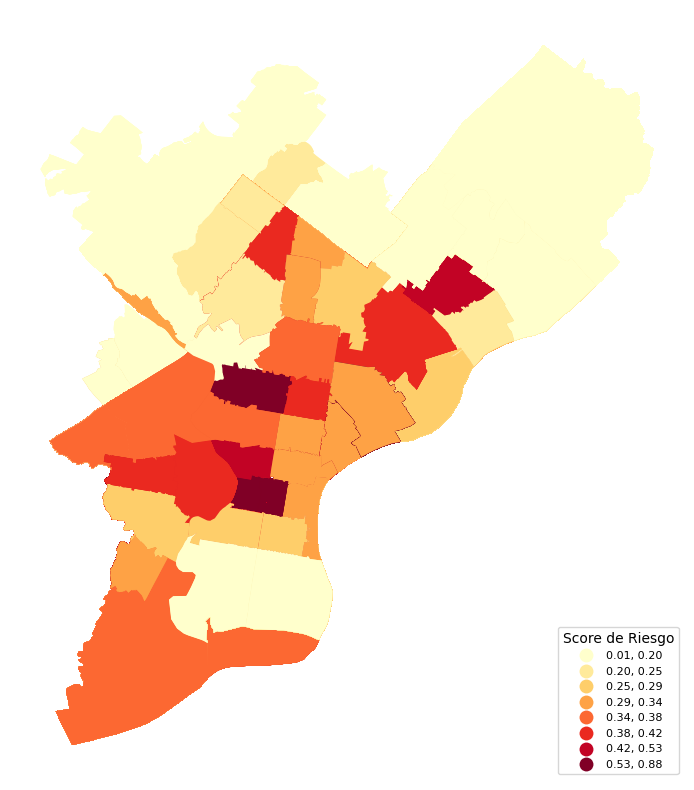

In [4]:
map=df_train.plot(column='risk_score', 
         scheme='quantiles',
         k=8, cmap='YlOrRd',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Score de Riesgo'} 
)
map.set_axis_off()    

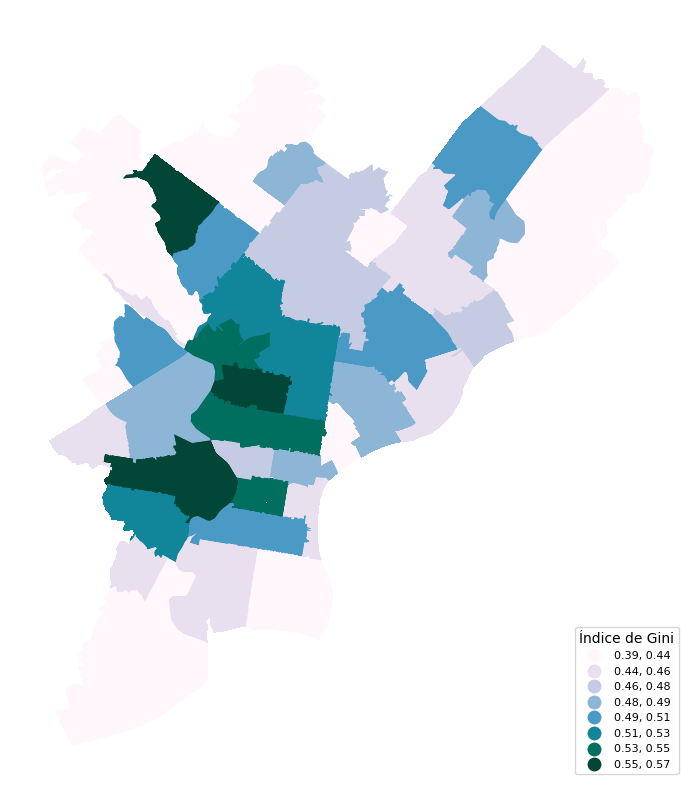

In [5]:
map=df_train.plot(column='GiniIndex', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Índice de Gini'} 
)
map.set_axis_off() 

# Matriz de pesos Espaciales

In [5]:
# Se hace agrupamiento
aggregate_df_train_raw = df_train.groupby(['ZCTA']).agg({
    'geometry': 'first',
    'population' : 'first', 
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# Se remueven NAs
aggregate_df_train = aggregate_df_train_raw.dropna().reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_train = gpd.GeoDataFrame(aggregate_df_train, geometry='geometry')
# Resumen 
aggregate_df_train.head(3)

,index,ZCTA,geometry,population,white_race,black_race,latino_race,asian_race,mean_income,median_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score
0,0,19004,"POLYGON ((-75.24583 40.02155, -75.24562 40.023...",10668,8284,529,448,998,217722.0,143781.0,4216,11.3,5.4,37.4,45.8,0.5115,0.056757
1,1,19012,"POLYGON ((-75.12187 40.05327, -75.12144 40.053...",6699,2792,2413,602,738,144838.0,117614.0,2237,5.4,10.6,46.1,37.8,0.4036,0.163073
2,2,19027,"POLYGON ((-75.15366 40.07214, -75.15332 40.072...",19170,8927,7207,1092,1231,136486.0,105190.0,8417,13.0,11.9,42.2,32.8,0.4608,0.036575


In [6]:
wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_15956\1756804908.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)


In [7]:
print(wq.n)

53


In [8]:
# No hay islas
wq.islands

[]

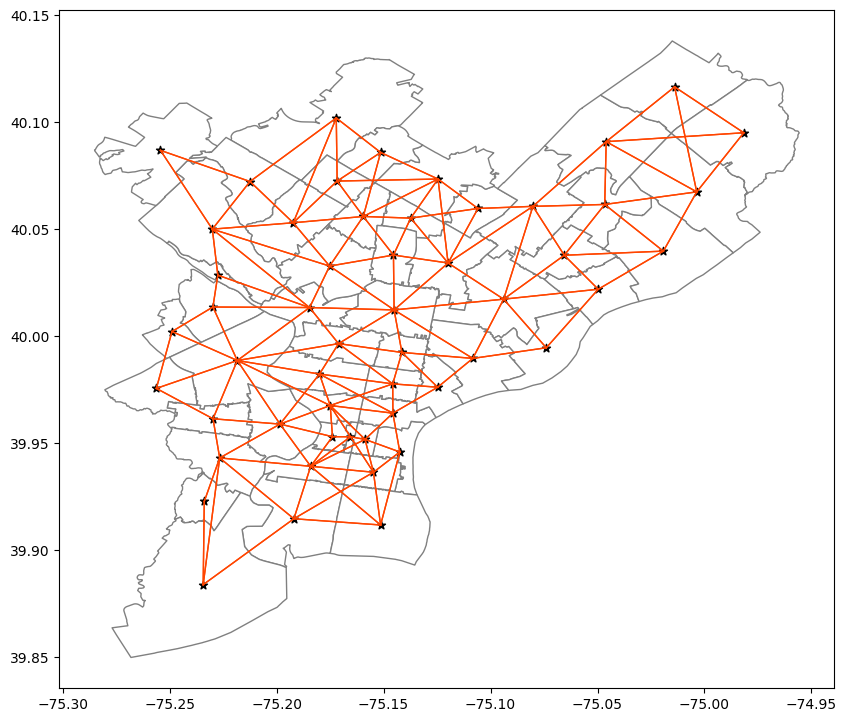

In [9]:
# Plot graph connections
ax = aggregate_df_train.plot(
        edgecolor="grey", facecolor="w",
        figsize=(10,10)
    )

wq.plot(
    aggregate_df_train,
    edge_kws=dict(linewidth=1, color="orangered"),
    node_kws=dict(marker="*"),
    ax=ax
)

plt.show()

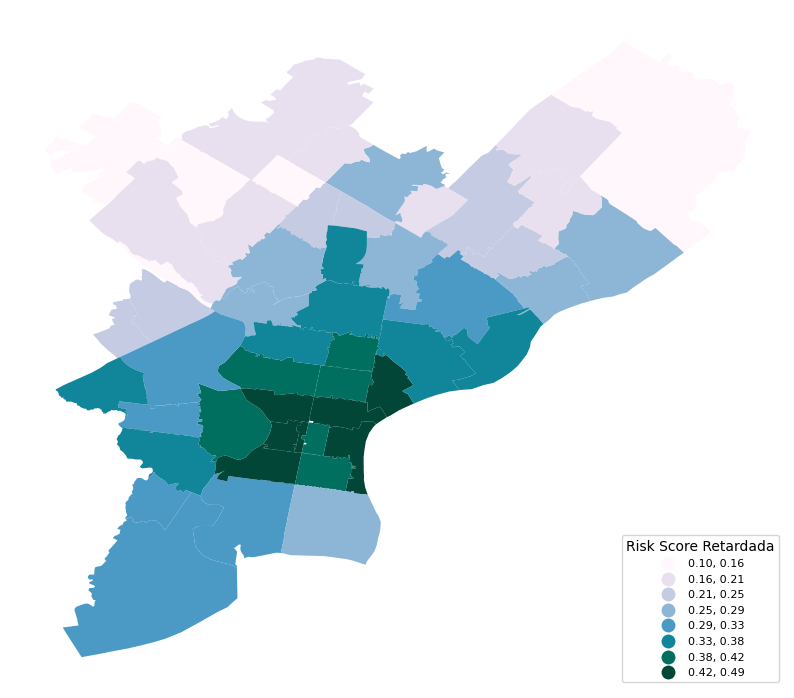

In [10]:
# Transformar pesos por filas
wq.transform = "R"

# Creación de variables con retardo espacial
aggregate_df_train["risk_score_lag"] = weights.spatial_lag.lag_spatial(
    wq, aggregate_df_train["risk_score"]
)

# representación de la tasa de paro retardada
map=aggregate_df_train.plot(column='risk_score_lag', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Risk Score Retardada'} 
)
map.set_axis_off() 

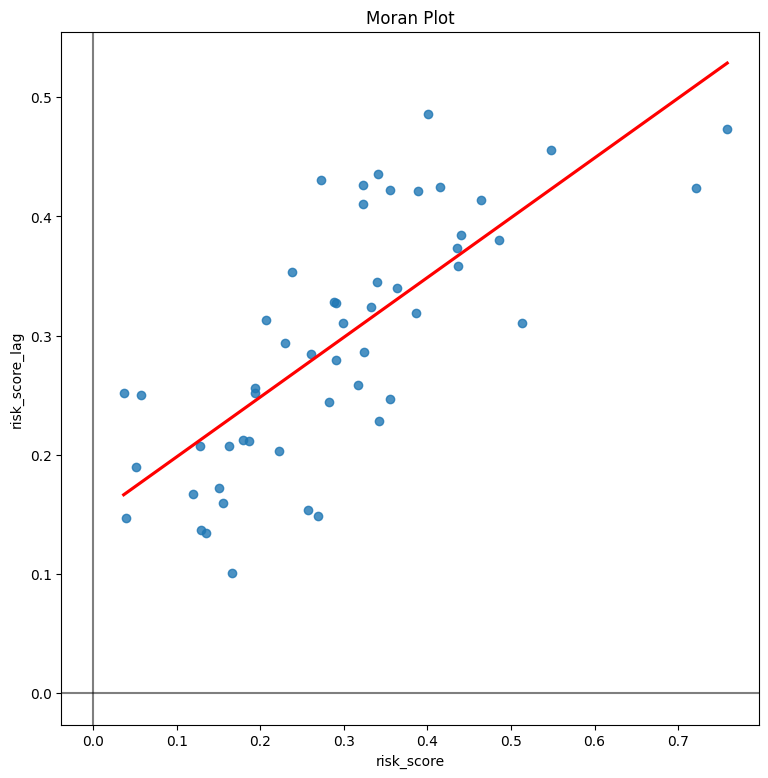

In [11]:
# AutoCorrelación Espacial
f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="risk_score",
    y="risk_score_lag",
    ci=None,
    data=aggregate_df_train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot")
plt.show()

In [12]:
# Correlación Espacial: La I de Moran
moran = esda.moran.Moran(aggregate_df_train["risk_score"], wq)
print("I de moran:", moran.I.round(3))
print("p-valor:", moran.p_sim)

I de moran: 0.502
p-valor: 0.001


In [14]:
#Correlación Espacial Local
lisa = esda.moran.Moran_Local(aggregate_df_train["risk_score"], wq, seed=42)

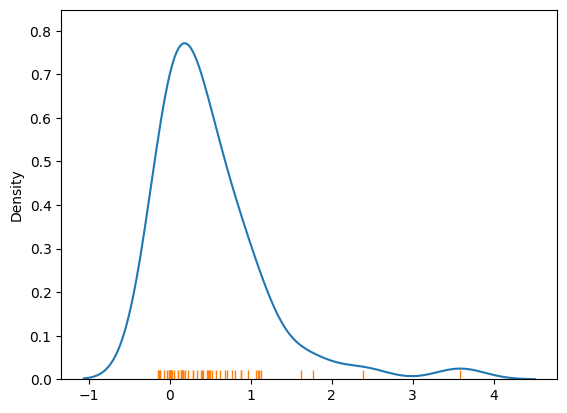

In [15]:
#Correlación Espacial Local
#Representación del Indice de Moran Local (Is)
# Draw KDE line
ax = sns.kdeplot(lisa.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
sns.rugplot(lisa.Is, ax=ax);

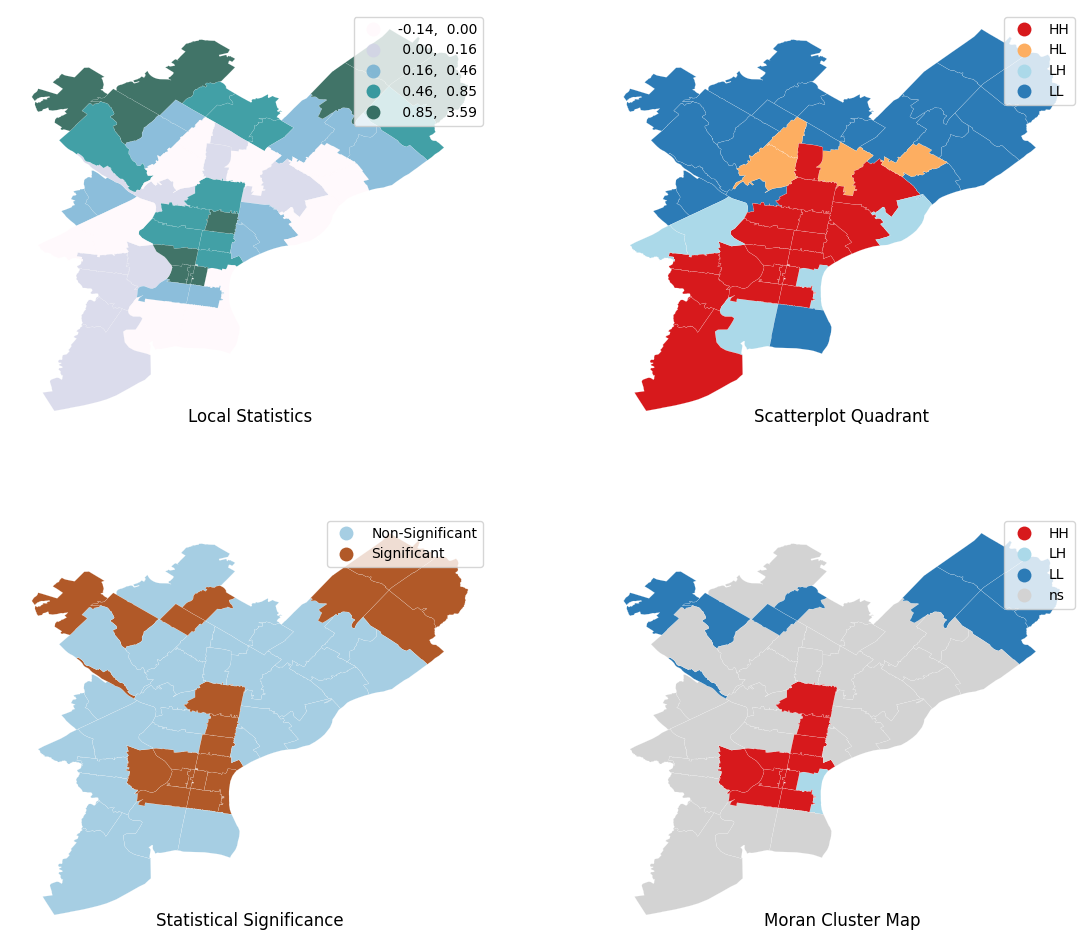

In [16]:
# Set up figure and axes
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
# Make the axes accessible with single indexing
axs = axs.flatten()

# Subplot 1 #
# Choropleth of local statistics
# Grab first axis in the figure
ax = axs[0]
# Assign new column with local statistics on-the-fly
aggregate_df_train.assign(
    Is=lisa.Is
    # Plot choropleth of local statistics
).plot(
    column="Is",
    cmap="PuBuGn",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    alpha=0.75,
    legend=True,
    ax=ax,
)

# Subplot 2 #
# Quadrant categories
# Grab second axis of local statistics
ax = axs[1]
# Plot Quandrant colors (note to ensure all polygons are assigned a
# quadrant, we "trick" the function by setting significance level to
# 1 so all observations are treated as "significant" and thus assigned
# a quadrant color
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=1, ax=ax)

# Subplot 3 #
# Significance map
# Grab third axis of local statistics
ax = axs[2]
#
# Find out significant observations
labels = pd.Series(
    1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
    index=aggregate_df_train.index  # Use the index in the original data
    # Recode 1 to "Significant and 0 to "Non-significant"
).map({1: "Significant", 0: "Non-Significant"})
# Assign labels to `db` on the fly
aggregate_df_train.assign(
    cl=labels
    # Plot choropleth of (non-)significant areas
).plot(
    column="cl",
    categorical=True,
    k=2,
    cmap="Paired",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax,
)


# Subplot 4 #
# Cluster map
# Grab second axis of local statistics
ax = axs[3]
# Plot Quandrant colors In this case, we use a 5% significance
# level to select polygons as part of statistically significant
# clusters
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=0.05, ax=ax)

# Figure styling #
# Set title to each subplot
for i, ax in enumerate(axs.flatten()):
    ax.set_axis_off()
    ax.set_title(
        [
            "Local Statistics",
            "Scatterplot Quadrant",
            "Statistical Significance",
            "Moran Cluster Map",
        ][i],
        y=0,
    )
# Tight layout to minimise in-betwee white space
# f.tight_layout()

# Display the figure
plt.show()

In [17]:
# Assign pseudo P-values to `gdfm`
aggregate_df_train["p-sim"] = lisa.p_sim
# `1` if significant (at 5% confidence level), `0` otherwise
sig = 1 * (lisa.p_sim < 0.05)
# Assign significance flag to `db`
aggregate_df_train["sig"] = sig

# Pick as part of a quadrant only significant polygons,
# assign `0` otherwise (Non-significant polygons)
spots = lisa.q * sig
# Mapping from value to name (as a dict)
spots_labels = {
    0: "Non-Significant",
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL",
}
# Create column in `db` with labels for each polygon
aggregate_df_train["labels"] = pd.Series(
    # First initialise a Series using values and `db` index
    spots,
    index=aggregate_df_train.index
    # Then map each value to corresponding label based
    # on the `spots_labels` mapping
).map(spots_labels)
# Print top for inspection
aggregate_df_train["labels"].value_counts()

labels
Non-Significant    32
HH                 11
LL                  9
LH                  1
Name: count, dtype: int64

# Modelado

## Modelo sin componente espacial

In [18]:
train = aggregate_df_train.copy()

In [20]:
#Regresión MCO
m1 = spreg.OLS(
    # Dependent variable
    train[["risk_score"]].values,
    # Independent variables
    train[["GiniIndex"]].values,
    # Dependent variable name
    name_y="risk_score",
    # Independent variable name
    name_x=["GiniIndex"]
)

print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :  risk_score                Number of Observations:          53
Mean dependent var  :      0.2943                Number of Variables   :           2
S.D. dependent var  :      0.1522                Degrees of Freedom    :          51
R-squared           :      0.3154
Adjusted R-squared  :      0.3020
Sum squared residual:    0.824992                F-statistic           :     23.4941
Sigma-square        :       0.016                Prob(F-statistic)     :   1.214e-05
S.E. of regression  :       0.127                Log likelihood        :      35.107
Sigma-square ML     :       0.016                Akaike info criterion :     -66.214
S.E of regression ML:      0.1248                Schwarz criterion     :     -62.274

------------------------------------------------------------

In [21]:
# Verificar dimensiones
print(f"Dimensiones de wq: {wq.n}")
print(f"Dimensiones de residuos: {len(m1.u)}")
print(f"Dimensiones de train: {len(train)}")

Dimensiones de wq: 53
Dimensiones de residuos: 53
Dimensiones de train: 53


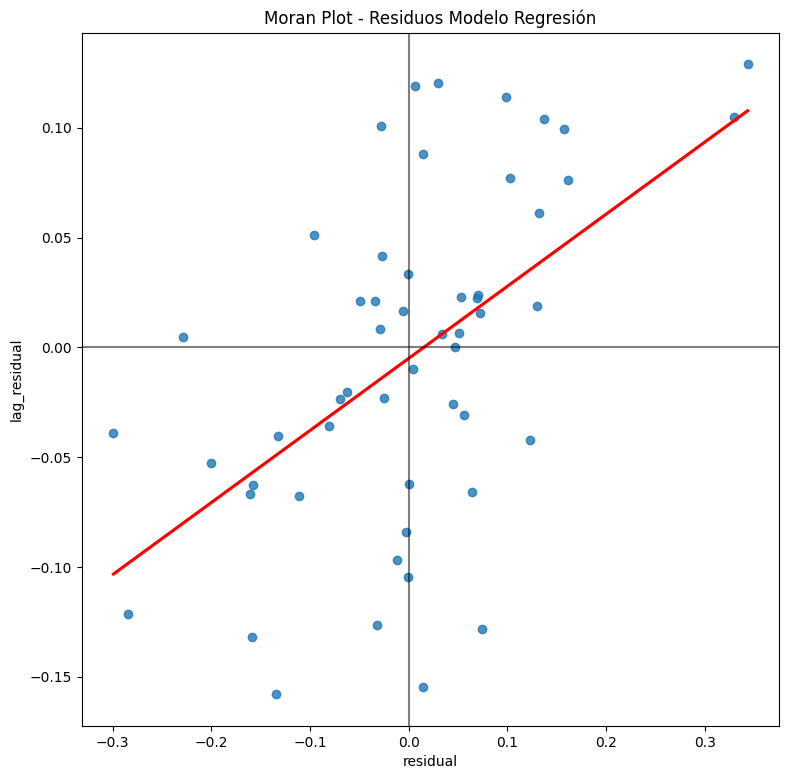

In [22]:
# Create column with residual values from m1
train["residual"] = m1.u
train["lag_residual"] = weights.spatial_lag.lag_spatial(wq, m1.u)

f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="residual",
    y="lag_residual",
    ci=None,
    data=train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - Residuos Modelo Regresión")
plt.show()

In [23]:
# Correlación Espacial: La I de Moran
moran = esda.moran.Moran(train["residual"], wq)
print("I de moran:", moran.I.round(3))
print("p-valor:", moran.p_sim)

I de moran: 0.328
p-valor: 0.001


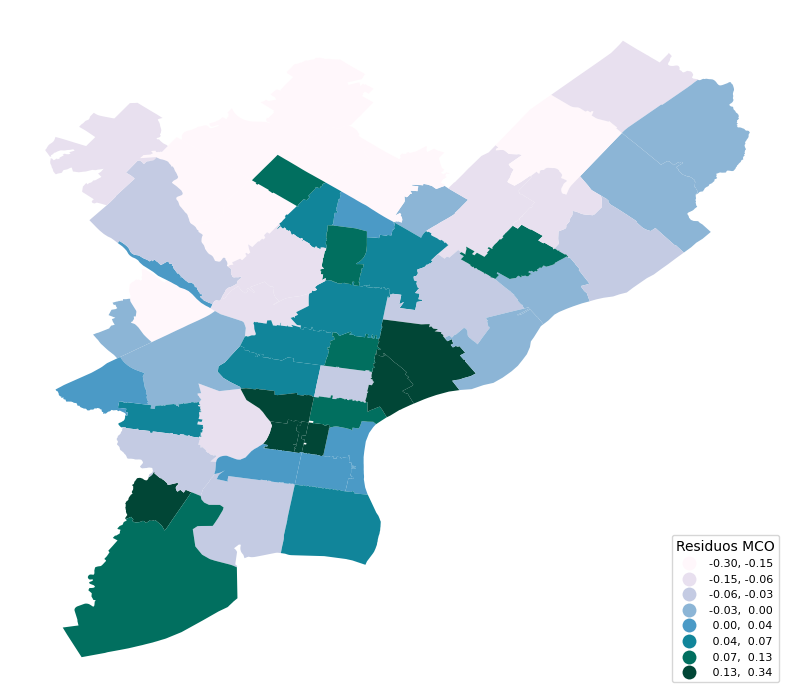

In [24]:
# representación de los residuos MCO  retardada
map=train.plot(column='residual', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Residuos MCO'} 
)
map.set_axis_off()

## Modelo Espacial

In [25]:
# Reordenar para que Morning sea la primera categoría alfabéticamente
train["time_of_day_reordered"] = train["time_of_day"].replace({
    'Afternoon': 'B_Afternoon',  # B para que sea segunda
    'Morning': 'A_Morning',      # A para que sea primera (se elimina)
    'Night': 'C_Night'           # C para que sea tercera
})

# Crear dummies (ahora Morning se eliminará)
dummies = pd.get_dummies(train["time_of_day_reordered"], prefix="time", drop_first=True)

# Limpiar nombres de columnas
dummies.columns = [col.replace('time_B_', 'time_').replace('time_C_', 'time_') 
                   for col in dummies.columns]

# Concatenar con tus features
X = pd.concat([train[["GiniIndex"]], dummies], axis=1).astype(float).values
y = train[["risk_score"]].values

KeyError: 'time_of_day'

In [47]:
# Concatenar con tus features
X = train[["mean_income"]].astype(float).values
y = train[["risk_score"]].values

In [48]:
# (Modelo autoregresivo espacial - estimado por MC2E)
mLag = spreg.GM_Lag(    
    # Dependent variable
    y=y,
    # Independent variables
    x=X,
    # Spatial weights matrix
    w= wq,
    robust='white',
    # Numero de retardos
    w_lags=10,
    #para el modelo de durbin slx_lags >0
    # slx_lags = 1, 
    #diagnósitico de correlación espacial
    spat_diag=True,
    # Dependent variable name
    name_y="risk_score",
    # Independent variable name
    name_x=["GiniIndex"], #, 'time_Afternoon', 'time_Night' 
    name_w=" Contiguidad Reina",
    name_ds=" Índice de Criminalidad en Filadelfia"
    
)

print(mLag.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            : Índice de Criminalidad en Filadelfia
Weights matrix      : Contiguidad Reina
Dependent Variable  :  risk_score                Number of Observations:          53
Mean dependent var  :      0.2943                Number of Variables   :           3
S.D. dependent var  :      0.1522                Degrees of Freedom    :          50
Pseudo R-squared    :      0.5871
Spatial Pseudo R-squared: omitted due to rho outside the boundary (-1, 1).

White Standard Errors
------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.01363         0.06231         0.21880         0.82681
           GiniIndex        -0.00

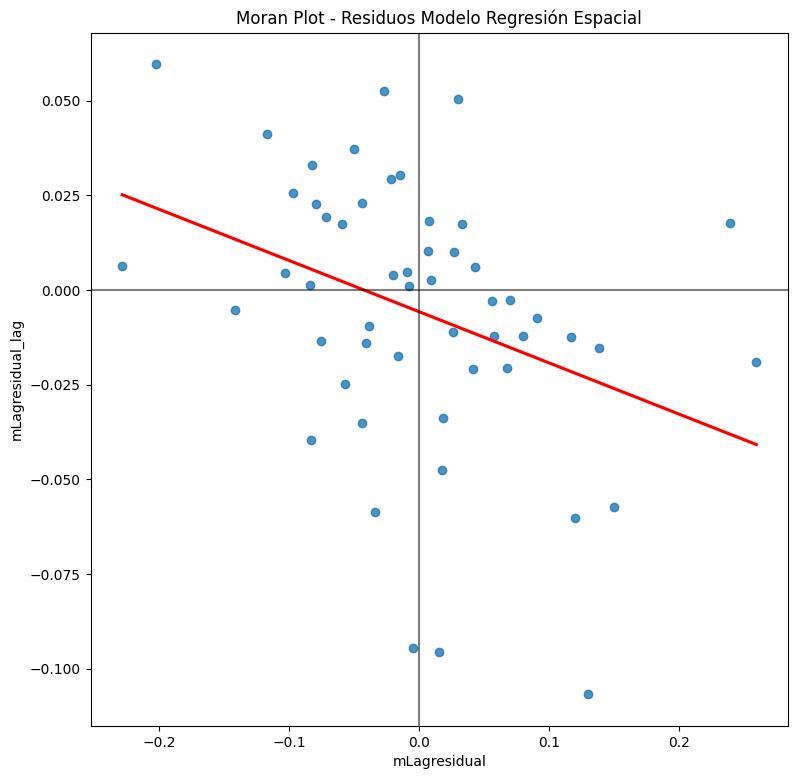

In [31]:
# Create column with residual values from m1
train["mLagresidual"] = mLag.u
train["mLagresidual_lag"] = weights.spatial_lag.lag_spatial(wq, mLag.u)

f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="mLagresidual",
    y="mLagresidual_lag",
    ci=None,
    data=train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - Residuos Modelo Regresión Espacial")
plt.show()

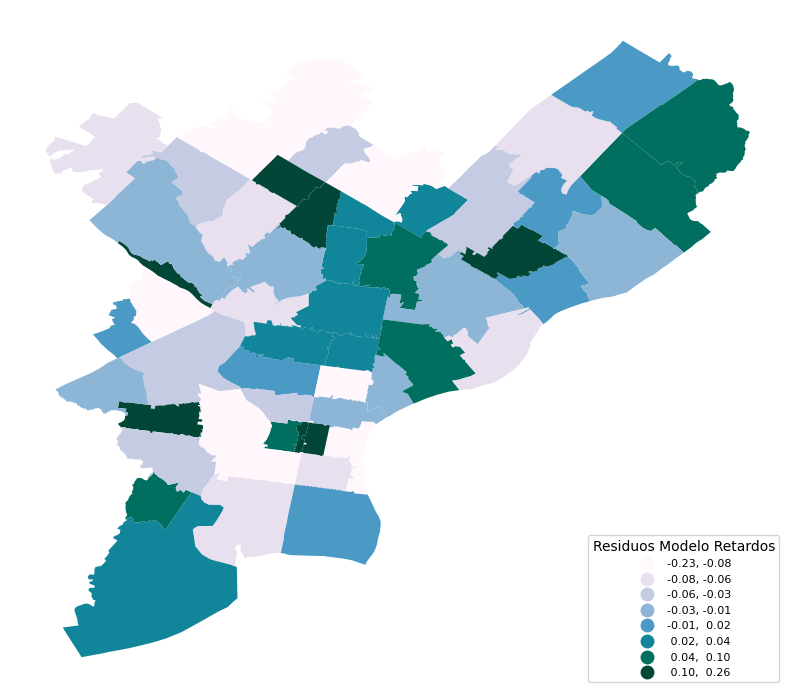

In [ ]:
# representación de los residuos Modelo Retardado
map=train.plot(column='mLagresidual', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Residuos Modelo Retardos'} 
)
map.set_axis_off() 


## Predicciones

In [33]:
df_val = cleanDataframe2(df=gpd.read_file('../Input/ModelingDatasets/Validation/df_val_with_score_ZCTACoordinates.shp'))
df_test = cleanDataframe2(df=gpd.read_file('../Input/ModelingDatasets/Test/df_test_with_score_ZCTACoordinates.shp'))

In [34]:
# Se hace agrupamiento
aggregate_df_val_raw = df_val.groupby(['ZCTA']).agg({
    'geometry': 'first',
    'population' : 'first',
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# Se remueven NAs
aggregate_df_val = aggregate_df_val_raw.dropna().reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_val = gpd.GeoDataFrame(aggregate_df_val, geometry='geometry')

In [35]:
val = aggregate_df_val.copy()

In [36]:
# Crear matriz de pesos de contigüidad reina para validación
wq_val = weights.Queen.from_dataframe(val)

# Normalizar (como hiciste en training)
wq_val.transform = 'r'

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_15956\2358686132.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq_val = weights.Queen.from_dataframe(val)


In [42]:
# Generar variables dummy
dummies = pd.get_dummies(val["time_of_day"], prefix="time", drop_first=True)

# Concatenar con tus features
X_val = pd.concat([val[["GiniIndex"]], dummies], axis=1).astype(float).values
y_val = val[["risk_score"]].values

In [37]:
# Concatenar con tus features
X_val = val[["GiniIndex"]].astype(float).values
y_val = val[["risk_score"]].values

In [38]:
betas = np.array(mLag.betas).flatten()
intercept = betas[0]
coefs = betas[1:-1]   # todas las covariables excepto rho
rho = betas[-1]

# Construcción de Xβ con todas las variables de una vez
Xbeta = intercept + X_val.dot(coefs)

In [39]:
# 3) Matriz de pesos espaciales (misma del entrenamiento)
W_val, ids = wq_val.full()
n = W_val.shape[0]

In [40]:
# 4) Resolver el sistema (I - rho W) y = Xβ
I = np.eye(n)
M = I - rho * W_val     
Xbeta_vec = Xbeta.reshape(-1, 1)

In [41]:
try:
    y_val_pred = np.linalg.solve(M, Xbeta_vec).flatten()
except np.linalg.LinAlgError:
    print("Advertencia: (I - rho W) es singular; usando pseudo-inversa")
    y_val_pred = np.linalg.pinv(M).dot(Xbeta_vec).flatten()

In [42]:
y_val.flatten()

array([0.02090115, 0.25404753, 0.44280361, 0.30916642, 0.15137116,
       0.14405612, 0.3471442 , 0.46921278, 0.11061625, 0.0694234 ,
       0.066656  , 0.07450853, 0.09585369, 0.11875529, 0.15368964,
       0.18985858, 0.20630857, 0.17994253, 0.14259455, 0.16244009,
       0.1718755 , 0.18800992, 0.06457007, 0.12383367, 0.19798795,
       0.12494249, 0.20187849, 0.2292762 , 0.16770028, 0.14079847,
       0.09430829, 0.12040845, 0.19069713, 0.23093031, 0.17956631,
       0.18970308, 0.19000094, 0.16969631, 0.14821428, 0.09306367,
       0.18044083, 0.20840598, 0.10413529, 0.1760663 , 0.16724204,
       0.16070613, 0.11408216, 0.0930386 , 0.06664318])

In [43]:
y_val_pred

array([0.26616378, 0.35915303, 0.42649114, 0.46925815, 0.5015079 ,
       0.33149257, 0.399459  , 0.16543436, 0.22685219, 0.06231106,
       0.16662557, 0.07738242, 0.42865163, 0.38130004, 0.31358127,
       0.48088483, 0.47065584, 0.36941788, 0.32253234, 0.32716228,
       0.32215575, 0.35846045, 0.32526248, 0.45359317, 0.38604982,
       0.44788377, 0.51045177, 0.44021872, 0.35586616, 0.23775584,
       0.13972058, 0.27377262, 0.33898752, 0.51970447, 0.4231813 ,
       0.35508732, 0.36089185, 0.44416105, 0.41895095, 0.3501512 ,
       0.41616605, 0.391824  , 0.30506201, 0.1936566 , 0.29422318,
       0.40626211, 0.17388925, 0.33943391, 0.03499051])

RMSE: 0.2077
R²:   -4.9347


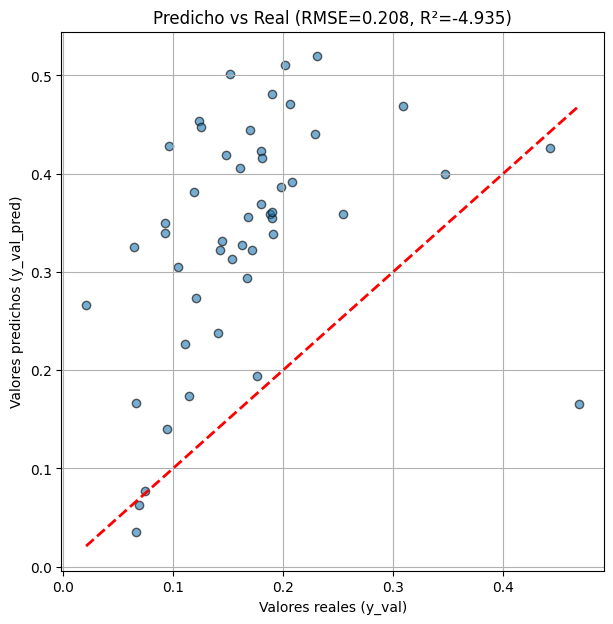

In [44]:
# 1) Valores reales y predichos
y_true = y_val.flatten()
y_pred = y_val_pred

# 2) Métricas
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# 3) Scatter plot Predicho vs Real
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor="k")
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Valores reales (y_val)")
plt.ylabel("Valores predichos (y_val_pred)")
plt.title(f"Predicho vs Real (RMSE={rmse:.3f}, R²={r2:.3f})")
plt.grid(True)
plt.show()